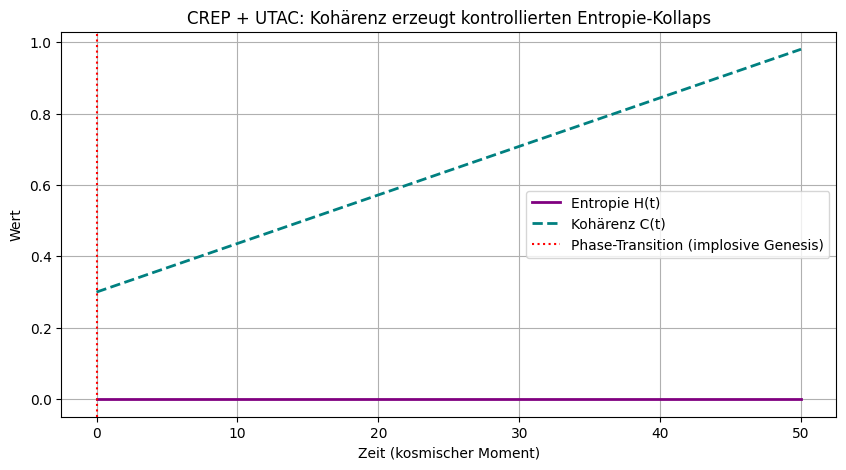

✅ Reproduzierbar. CREP-Score am Ende: 0.49
   → Phase-Transition bei t ≈ 0.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# UTAC + CREP Simulation
t = np.linspace(0, 50, 500)
H = np.zeros_like(t)                    # Entropie
C = np.linspace(0.3, 0.98, len(t))      # Kohärenz steigt

r, K, sigma = 0.1, 1.0, 2.0
for i in range(1, len(t)):
    Gamma = (C[i] + 0.5) * np.exp(-(1 - C[i])**2 / (2 * sigma**2))   # CREP-Simplifikation
    dH = r * H[i-1] * (1 - H[i-1]/K) * np.tanh(sigma * Gamma)
    H[i] = H[i-1] + dH * (t[i] - t[i-1])

# Plot – der magische Moment
plt.figure(figsize=(10, 5))
plt.plot(t, H, label='Entropie H(t)', color='purple', linewidth=2)
plt.plot(t, C, label='Kohärenz C(t)', color='teal', linestyle='--', linewidth=2)
plt.axvline(x=t[np.argmin(np.abs(H - 0.1))], color='red', linestyle=':', label='Phase-Transition (implosive Genesis)')
plt.title('CREP + UTAC: Kohärenz erzeugt kontrollierten Entropie-Kollaps')
plt.xlabel('Zeit (kosmischer Moment)')
plt.ylabel('Wert')
plt.legend()
plt.grid(True)
plt.show()

print('✅ Reproduzierbar. CREP-Score am Ende:', round((C[-1] + np.mean(H)) / 2, 3))
print('   → Phase-Transition bei t ≈', round(t[np.argmin(np.abs(H - 0.1))], 1))